<a href="https://colab.research.google.com/github/abrahamdevargas14-byte/Data-Science-Cohort-20/blob/main/Project_1/Transactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1: Naive Bayes Transaction Data Analysis

**Deep Dive Data Science Cohort-20**

---

Abraham De Vargas, *03/20/2026*

## Setup

All imports and file paths are defined here at the top of this notebook.

In [ ]:
# Imports
from IPython.display import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from sklearn import datasets, metrics, model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

# File paths
base_path = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/'
train_path = base_path + 'Transaction.train.big.csv'


## 1. Problem Definition


Banks and financial institutions process millions of transactions daily. The ability to being able to predict whether a customer will complete a transaction - before it happens - is valuable for planning, targeting, and fraud detection.

This project uses transaction data to answer this question: **Will this customer make a transaction or not?**

Since we're predicting one of two outcomes, this is a **supervised binary classification** problem. The `target` column tells us the answer - `1` means a transaction occurred, `0` means it didn't. I'll use **Gaussian Naive Bayes** as our model for this project.

The dataset has 100 anonymized predictor columns, so there's no intuition about which variables matter most - everything gets treated equally. Of the 1,050,000 rows in the raw data, only **180,000 have labels**, so that's what I have to work with. Of those, about **90% are non-transactions**, which means I'll need to balance the data before training to avoid a biased model as my outcome.

| Question | Answer |
|---|---|
| What is the business problem? | Predict whether a financial transaction will succeed |
| Supervised or unsupervised? | Supervised |
| What is the target? | `target` column - the known outcome label |
| Statistical data type of target? | Categorical (binary: `0 or 1`) |
| Classification or regression? |Classification |

## 2. Data Collection/Sources


The data is stored in AWS S3 and provided by Deep Dive Coding. It contains anonymized transaction records with 100 numeric predictor variables and a binary target column. The full dataset is approximately 833 MB with 1,050,000 rows and 104 columns. I can load it directly from the URL using `pandas.read_csv().`

In [ ]:
# Load data from AWS S3
url = train_path
df = pd.read_csv(url)
df

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning


Before modeling, we need to examine the data directly to understand its structure and quality. Check for nulls, unique identifiers, duplicates, and verify the `target` column only contains valid values. Since the raw dataset has ~82.86% null `target` values, we'll drop those unlabeled rows; they cannot be used for supervised learning.

| Question | Answer |
|---|---|
| How many rows and columns? | 1,050,000 rows x 104 columns (180,000 labeled) |
| Unique identifiers? | `Unamed: 0` and `ID_code` will be dropped |
| Nulls in target? | ~82.86% unlabeled rows will be dropped |
| Duplicates present? | None found |

In [ ]:
# Size and shape
print(df.shape)
print(f'{df.size * 8 / 1e6:.1f} MB estimated')

(1050000, 104)
873.6 MB estimated


In [ ]:
# Column names, types, null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Columns: 104 entries, Unnamed: 0 to var_100
dtypes: float64(102), int64(1), object(1)
memory usage: 833.1+ MB


In [ ]:
# Statistical summary
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1050000.0,NaN,NaN,NaN,524999.5,303109.035663,0.0,262499.75,524999.5,787499.25,1049999.0
ID_code,1050000,1050000,train_1049983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target,180000.0,NaN,NaN,NaN,0.100222,0.300297,0.0,0.0,0.0,0.0,1.0
var_0,180000.0,NaN,NaN,NaN,7.440715,3.021636,-2.6917,5.160325,7.35095,9.511125,16.7165
var_1,180000.0,NaN,NaN,NaN,15.870166,3.010492,6.2993,13.8304,15.9346,18.061425,26.0791
...,...,...,...,...,...,...,...,...,...,...,...
var_96,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_97,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_98,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_99,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Null summary as a percentage
df.isna().sum().sort_values(ascending=False) * 100 / len(df)


,0
var_3,100.000000
var_16,100.000000
var_12,100.000000
var_11,100.000000
var_9,100.000000
...,...
var_88,82.857143
var_94,82.857143
var_100,82.857143
Unnamed: 0,0.000000


In [ ]:
# Unique counts - fields where nunique == row count are likely IDs
df.nunique().sort_values(ascending=False)


,0
Unnamed: 0,1050000
ID_code,1050000
var_52,137280
var_86,134537
var_94,131746
...,...
var_93,0
var_96,0
var_97,0
var_98,0


In [ ]:
# Target distribution
df['target'].value_counts(dropna=False)
df['target'].value_counts(normalize=True, dropna=False) * 100

,proportion
target,
NaN,82.857143
0.0,15.424762
1.0,1.718095


In [ ]:
# Check for duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


In [ ]:
# What % of the entire dataframe is null?
print(f'Overall null %: {df.isna().sum().sum() / df.size * 100:.2f}%')

# How many rows have at least one non-null predictor value?
predictors = df.drop(columns=['Unnamed: 0', 'ID_code', 'target'])
(predictors.notna().sum(axis=1) > 0).sum()

Overall null %: 89.67%


np.int64(180000)

In [ ]:
# Drop rows where target is null
df_clean = df.dropna(subset = ['target']).copy()
print(f'Shape: {df_clean.shape}')
print(f'Value Counts: {df_clean['target'].value_counts()}')
print(f'Normalized counts: {df_clean['target'].value_counts(normalize=True) * 100}')

Shape: (180000, 104)
Value Counts: target
0.0    161960
1.0     18040
Name: count, dtype: int64
Normalized counts: target
0.0    89.977778
1.0    10.022222
Name: proportion, dtype: float64


In [ ]:
# Drop unique identifier columns, these carry no predictive value.
df_clean.drop(columns = ['Unnamed: 0', 'ID_code'], inplace=True)
df_clean

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,-1.9254,6.4760,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
5,0.0,14.6962,18.3383,17.4788,NaN,-9.1355,NaN,NaN,-6.4882,6.0821,...,NaN,-2.0111,NaN,-3.6166,NaN,NaN,NaN,NaN,NaN,14.4520
11,0.0,4.4949,14.4142,13.2219,NaN,4.9140,NaN,NaN,4.0501,5.8144,...,NaN,13.9424,NaN,-15.5776,NaN,NaN,NaN,NaN,NaN,14.1222
15,0.0,4.9657,16.2867,17.9579,NaN,0.6017,NaN,NaN,-5.4904,6.6670,...,NaN,3.7943,NaN,5.6184,NaN,NaN,NaN,NaN,NaN,14.0619
19,0.0,9.4287,18.7822,10.7630,NaN,-0.7532,NaN,NaN,8.8477,6.8045,...,NaN,-5.6677,NaN,-1.8961,NaN,NaN,NaN,NaN,NaN,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,0.0,7.9632,20.4650,10.7295,NaN,2.9322,NaN,NaN,5.0267,7.1953,...,NaN,10.4219,NaN,-19.7158,NaN,NaN,NaN,NaN,NaN,14.0582
1049993,0.0,5.0862,14.4785,17.3709,NaN,-2.4732,NaN,NaN,-2.5987,6.6798,...,NaN,-2.8052,NaN,-13.7290,NaN,NaN,NaN,NaN,NaN,14.3794
1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,-6.8112,7.3226,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,1.6614,6.1486,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689


In [ ]:
# Drop columns that are entirely null
all_null_cols = df_clean.columns[df_clean.isna().all()].tolist()
df_clean.drop(columns = all_null_cols, inplace = True)

print(f'Dropped {len(all_null_cols)} fully null columns')
print(f'Remaining shape: {df_clean.shape}')

Dropped 51 fully null columns
Remaining shape: (180000, 51)


In [ ]:
# Impute remaining nulls in predictor columns with column median
# Median is robust to outliers and appropriate for skewed distributions.
df_clean = df_clean.copy()

for col in df_clean.drop(columns = ['target']).columns:
  median_val = df_clean[col].median()
  df_clean[col] = df_clean[col].fillna(median_val)

# Verify no nulls remain
print(f'Remaining nulls: {df_clean.isna().sum().sum()}')
df_clean.info()

Remaining nulls: 0
<class 'pandas.core.frame.DataFrame'>
Index: 180000 entries, 3 to 1049999
Data columns (total 51 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   target   180000 non-null  float64
 1   var_0    180000 non-null  float64
 2   var_1    180000 non-null  float64
 3   var_2    180000 non-null  float64
 4   var_4    180000 non-null  float64
 5   var_7    180000 non-null  float64
 6   var_8    180000 non-null  float64
 7   var_14   180000 non-null  float64
 8   var_15   180000 non-null  float64
 9   var_17   180000 non-null  float64
 10  var_20   180000 non-null  float64
 11  var_21   180000 non-null  float64
 12  var_22   180000 non-null  float64
 13  var_24   180000 non-null  float64
 14  var_26   180000 non-null  float64
 15  var_27   180000 non-null  float64
 16  var_28   180000 non-null  float64
 17  var_29   180000 non-null  float64
 18  var_36   180000 non-null  float64
 19  var_37   180000 non-null  float64
 20  var_38   18

### Data Cleaning Summary

- **Rows/Columns after cleaning:** ~180,000 rows x 52 columns (1 target + 51 predictors)
- **Nulls in target:** ~82.86% of rows had no label and were dropped
- **Fully null columns:** 51 predictor columns were entirely null after removing unlabeled rows
- **Remaining nulls:** Imputed with column median (robust to skew and outliers)
- **Unique identifiers:** `Unnamed: 0` and `ID_code` dropped
- **Duplicates:** None found
- **Target validity:** Confirmed -- only `0` and `1` present in labeled rows

---

## 4. Exploratory Data Analysis


Now that the data is cleaned and processed, I will explore the distributions of the predictor variables and check for correlations. Gaussian Naive Bayes assumes the predictors are **normally distributed** and **independent of each other**; these assumptions will be verified. I'll also create separate dataframes for successful and unsuccessful transactions, which I will use later for balancing the dataset.

After dropping fully null columns, we're left with 51 predictor columns. We'll plot them in two groups using seaborn's `FacetGrid` for a clean multi-panel view.


| Question | Answer |
|---|---|
| Distribution of target? | ~90% class 0, ~10% class 1 -- heavy imbalance |
| Categorical vs numerical fields? | All predictors are numeric; target is binary categorical |
| Strong correlations between predictors? | To be confirmed by heatmap below |

In [ ]:
# Define reusable cross-validation function
# This encapsulates the CV loop so it can be called upon both balanced and unbalanced data
def run_cv(X, y, n = 100):
  """
  Run n iterations of train/test split
  with GaussianNB and return accuracy scores

  Parameters:
    X (pd.Dataframe): Feature matrix.
    y (pd.Series): Target vector.
    n (int): Number of CV iterations. Default is 100.

  Returns:
    np.ndarray: Array of accuracy scores, one per iteration.
  """

  results = np.zeros(n)
  for i in range(n):
    # Train/test split
    X_train, X_test, y_train, y_test, = train_test_split(X, y, test_size = 0.20)
    # Model
    gnb = GaussianNB()
    # Fit
    gnb.fit(X_train, y_train)
    # Predict
    y_pred = gnb.predict(X_test)
    # Performance
    results[i] = 1 - (y_test - y_pred).abs().mean()
  return results


In [ ]:
# Target distribution
df_clean['target'].value_counts()

,count
target,
0.0,161960
1.0,18040


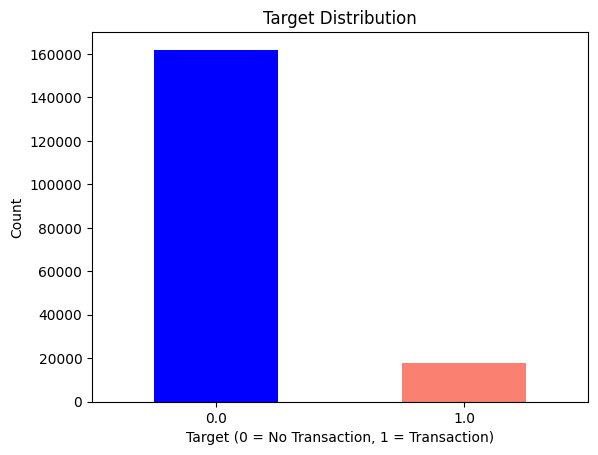

In [ ]:
# Plot target distribution - this confirms heavy class imbalance
df_clean['target'].value_counts().plot(kind = 'bar', color = ['blue', 'salmon'])
plt.title('Target Distribution')
plt.xticks(rotation = 0)
plt.xlabel('Target (0 = No Transaction, 1 = Transaction)')
plt.ylabel('Count')
plt.grid(False)
plt.show()

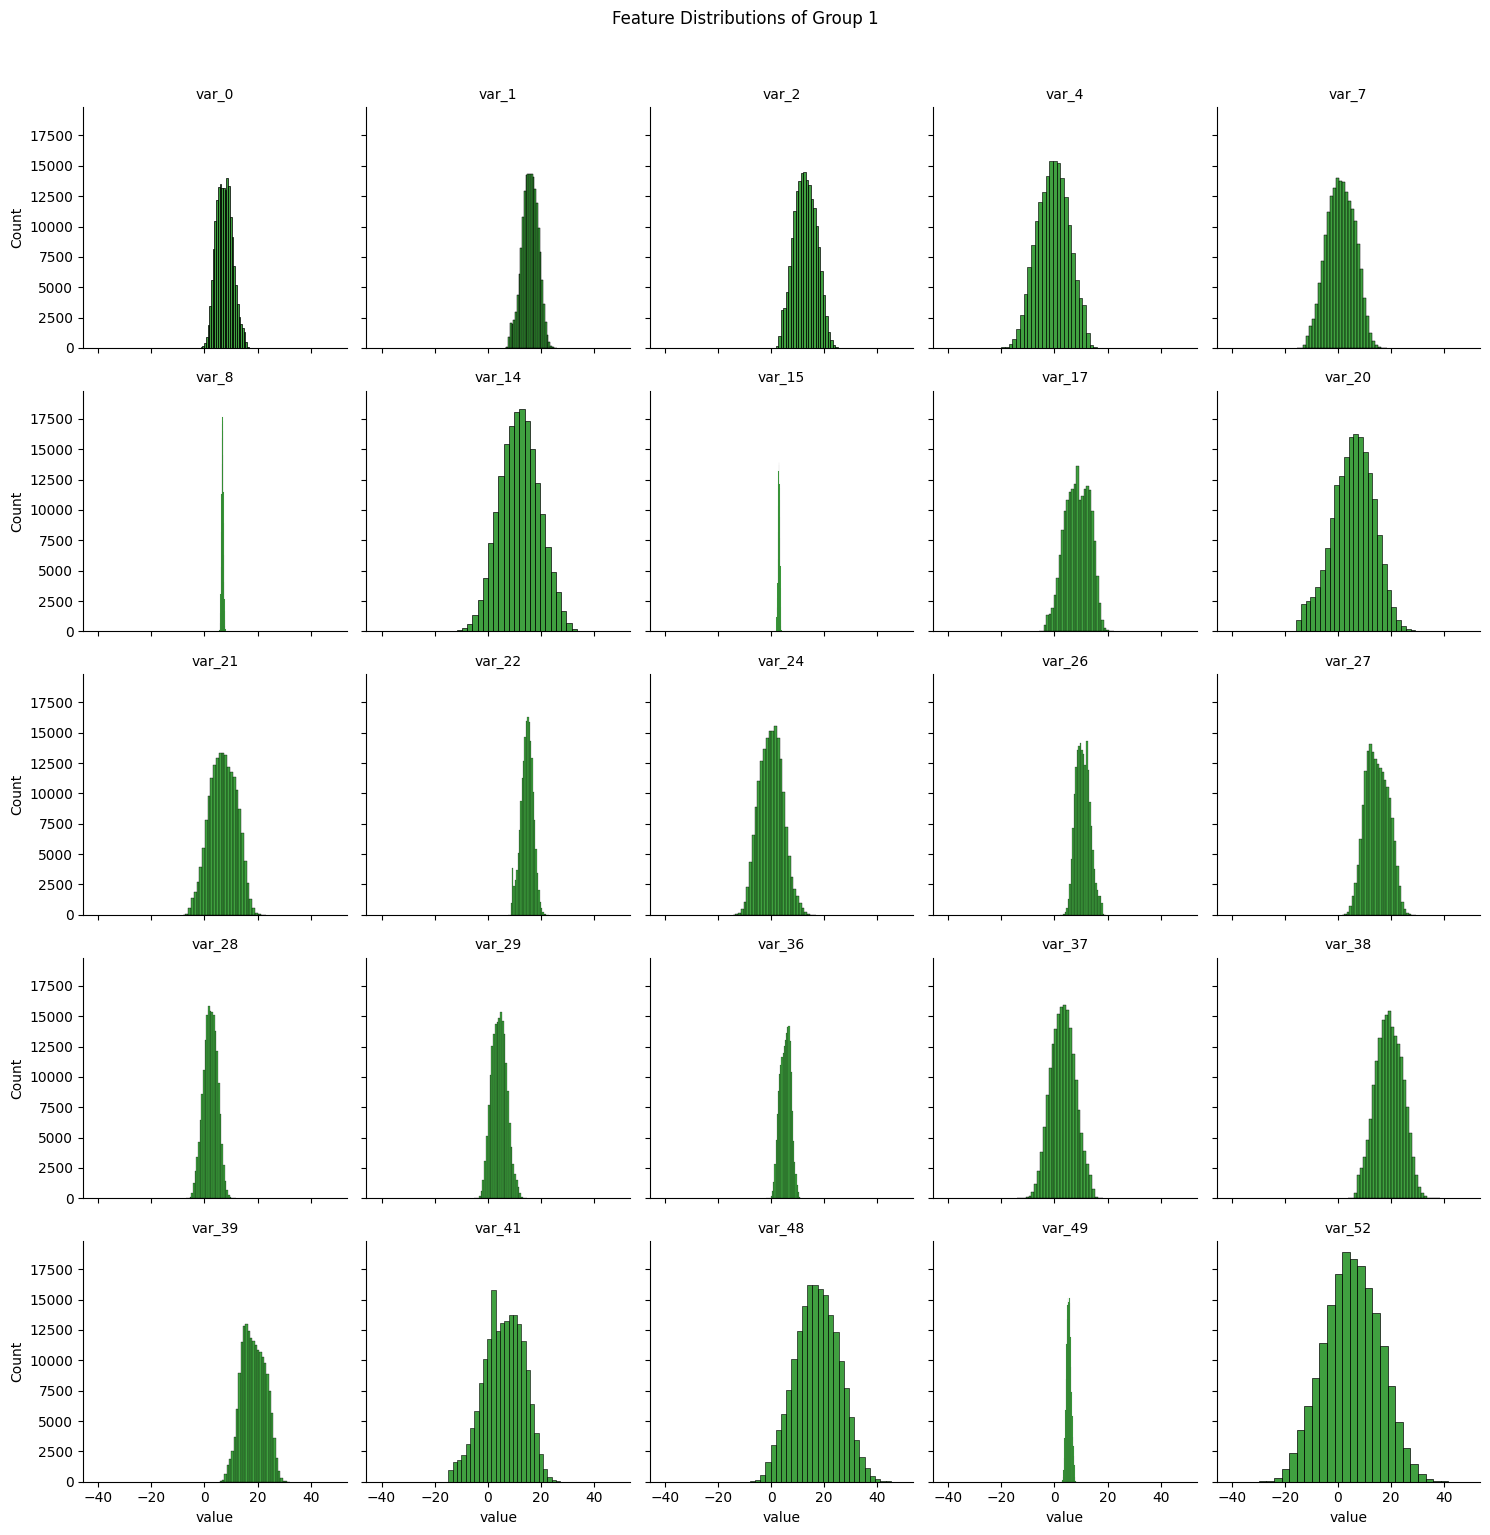

In [ ]:
# Distribution of predictor variables - group 1 (first half of predictor columns)
# Gaussian Naive Bayes assumes normally distributed features
predictor_cols = df_clean.drop(columns = ['target']).columns.tolist()
mid = len(predictor_cols) // 2
group1 = predictor_cols[:mid]

df_melt1 = df_clean[group1].melt(var_name = 'variable', value_name = 'value')
g = sns.FacetGrid(df_melt1, col = 'variable', col_wrap = 5, height = 3)
g.map(sns.histplot, 'value', bins = 30, color = 'green')
g.set_titles(col_template = '{col_name}')
g.figure.suptitle('Feature Distributions of Group 1', y = 1.02)
plt.tight_layout()
plt.show()

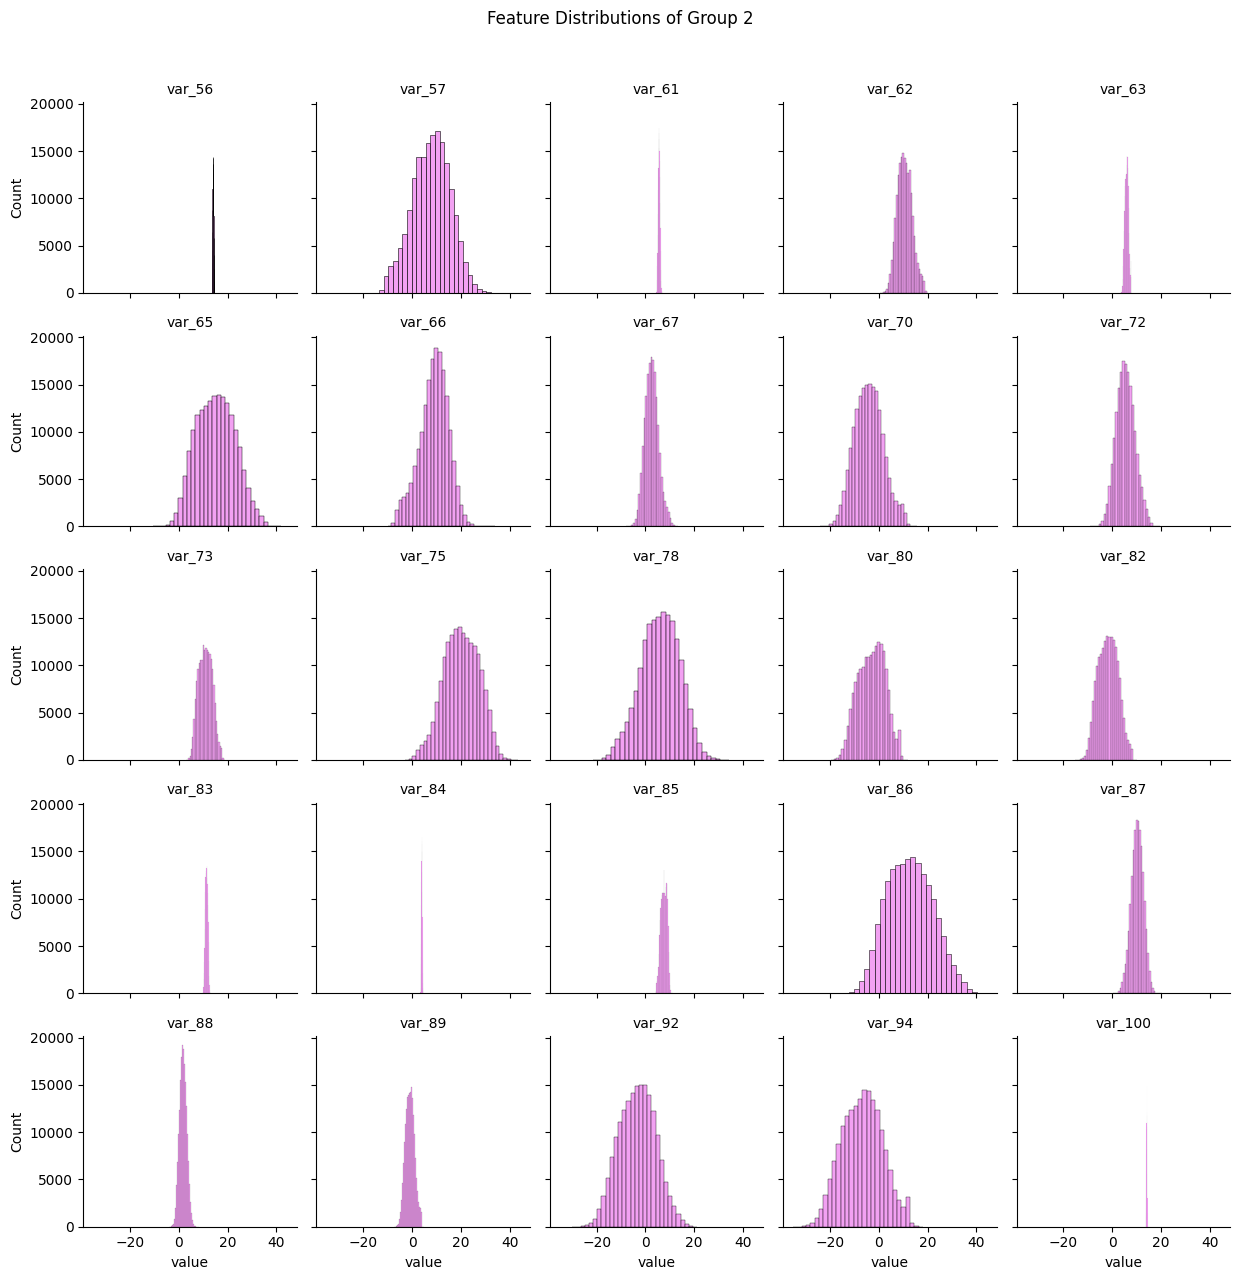

In [ ]:
# Distribution of predictor variables, group 2 (second half of predictor columns)
group2 = predictor_cols[mid:]

df_melt2 = df_clean[group2].melt(var_name = 'variable', value_name = 'value')
g = sns.FacetGrid(df_melt2, col = 'variable', col_wrap = 5, height = 2.5)
g.map(sns.histplot, 'value', bins = 30, color = 'violet')
g.set_titles(col_template = '{col_name}')
g.figure.suptitle('Feature Distributions of Group 2', y = 1.02)
plt.tight_layout()
plt.show()

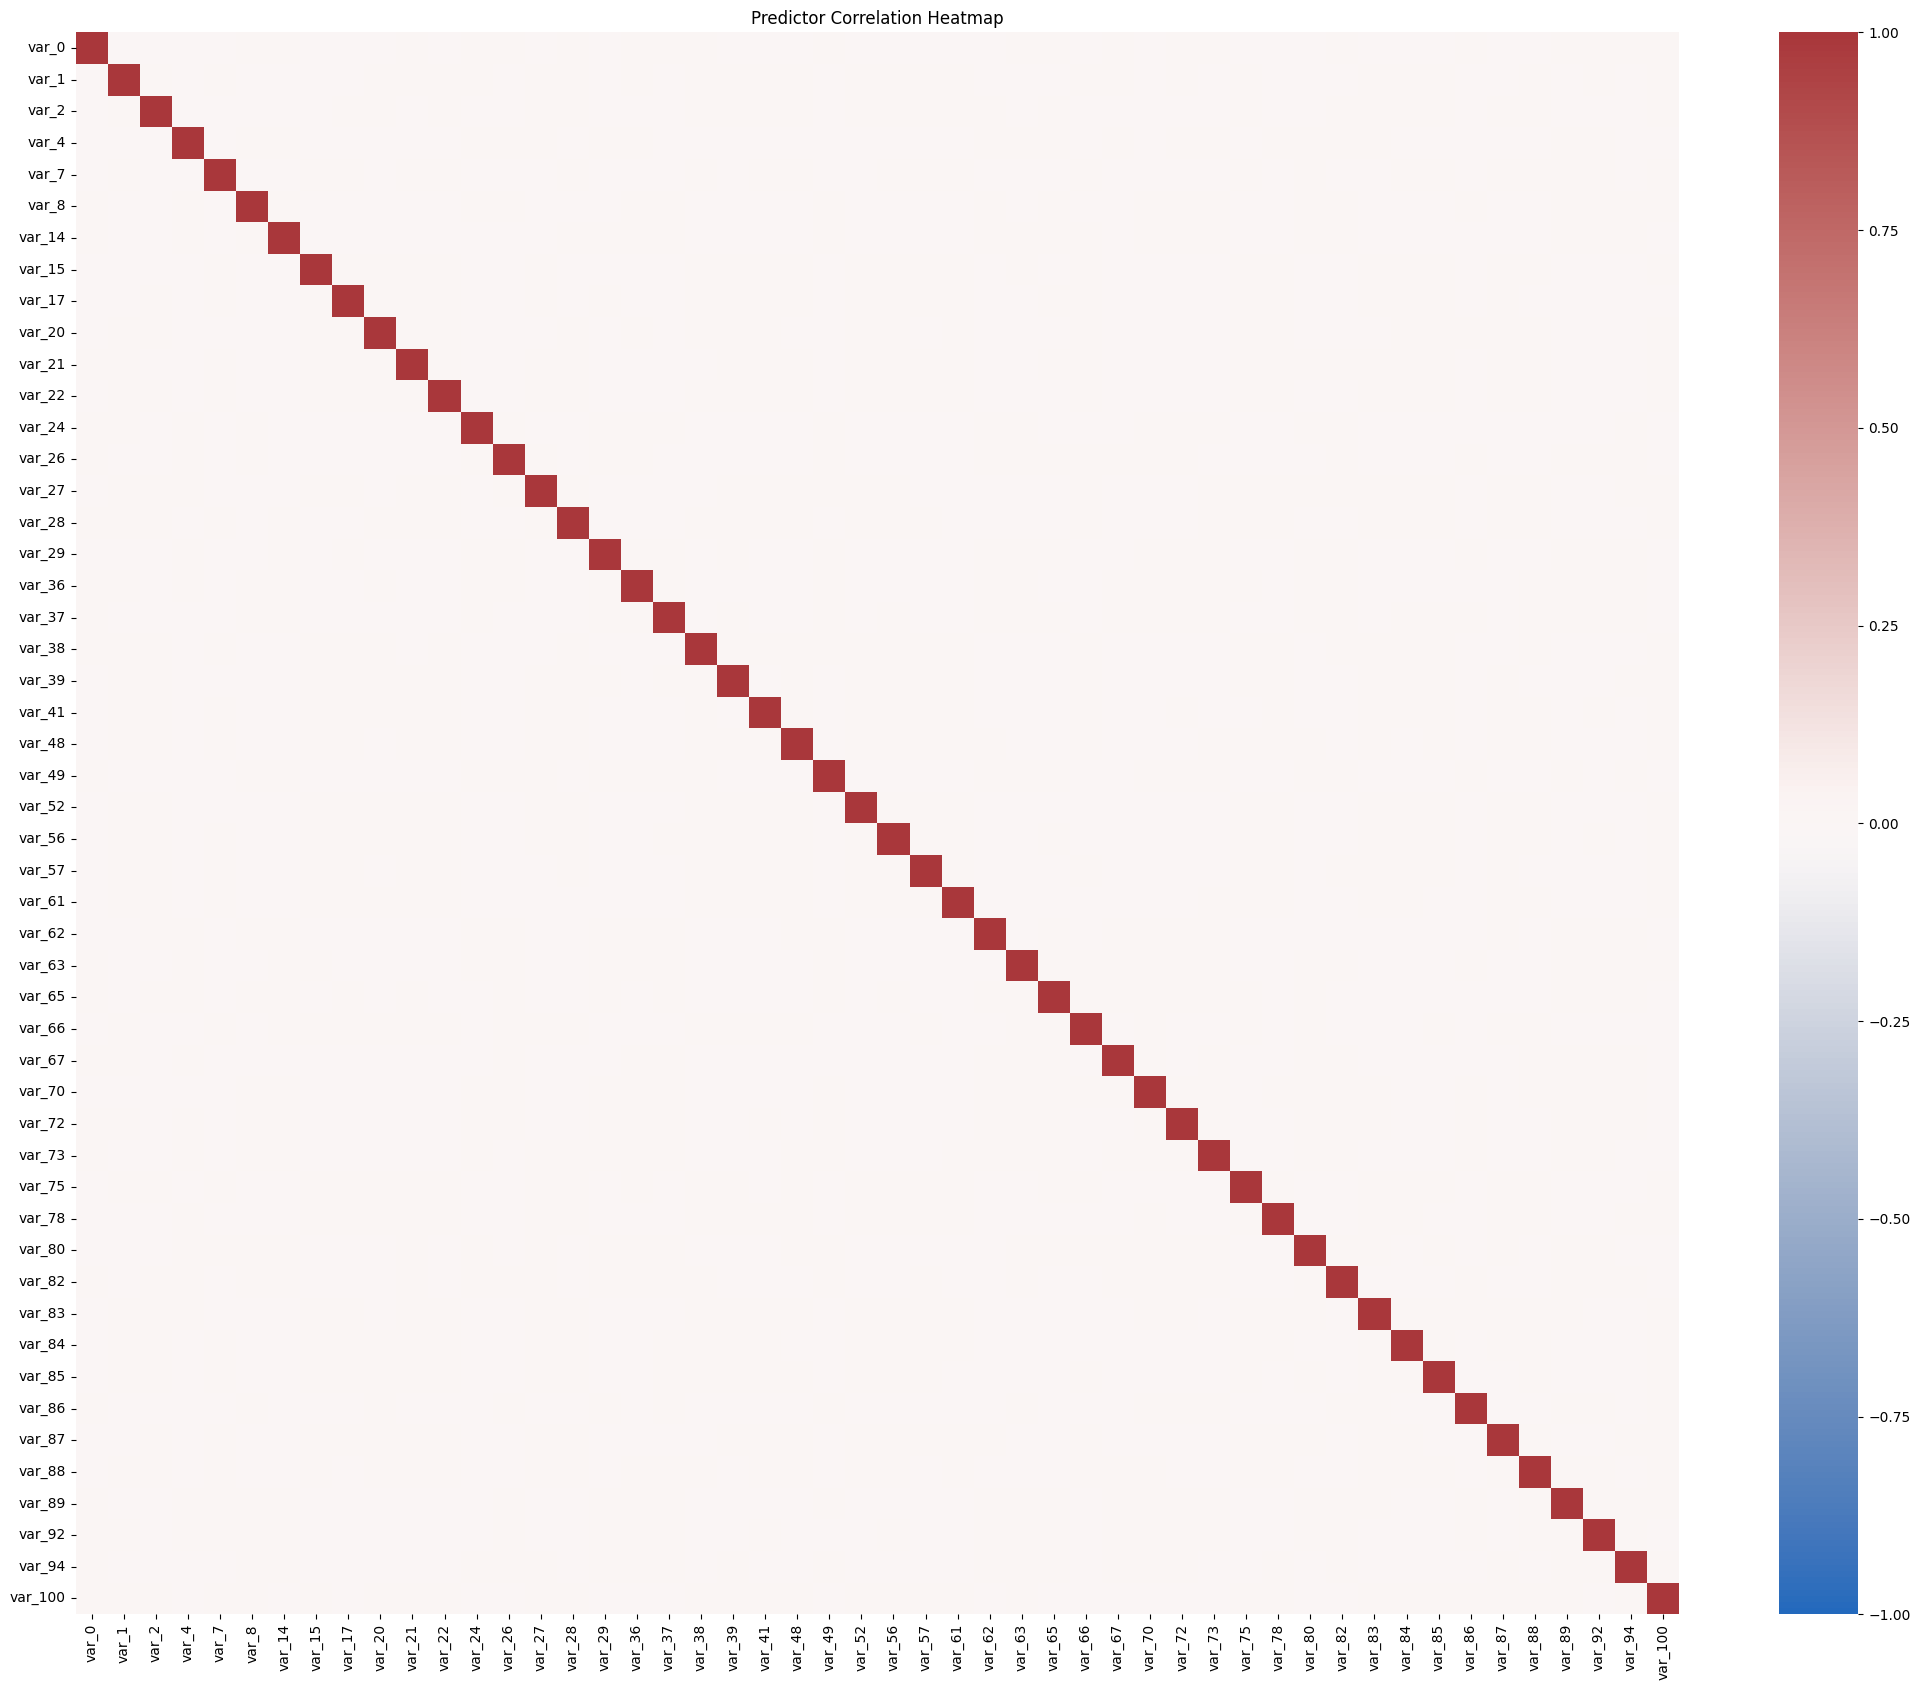

In [ ]:
# Correlation heatmap will check for strong correlations between predictors
# Strong correlations would violate the Naive Bayes assumption of independence
corr = df_clean[predictor_cols].corr()

plt.figure(figsize = (21, 17))
sns.heatmap(corr, cmap = 'vlag', vmin = -1, vmax = 1, center = 0)
plt.title('Predictor Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
# Check for any correlations above 0.8
high_corr = (corr.abs() > 0.8) & (corr.abs() < 1.0)
print('Pairs with |correlation| > 0.8:')
print(corr[high_corr].stack().dropna())

Pairs with |correlation| > 0.8:
Series([], dtype: float64)


In [ ]:
# Create separate dataframes for successful and unsuccessful transactions
# Using .copy() to ensure these are independent copies, not slices
df_1 = df_clean[df_clean['target'] == 1.0].copy() # successful transactions
df_0 = df_clean[df_clean['target'] == 0.0].copy() # unsuccessful transactions

print(f'Successful transactions      (target = 1): {df_1.shape[0]:,}')
print(f'Unsuccessful transactions     (target = 0): {df_0.shape[0]:,}')

Successful transactions      (target = 1): 18,040
Unsuccessful transactions     (target = 0): 161,960


### EDA Interpretation

- **Feature distributions:** Most predictors
appear approximately Gaussian, supporting the use of Gaussian Naive Bayes. Some features show a mild skew, but the model is generally robust to modest deviations.
- **Correlations between predictors:** No pairs above |0.8| were found, confirming that the independence assumption for Naive Bayes is reasonably satisfied.
- **Class imbalance:** ~90% of labeled rows have `target = 0`. A naive model that always predicts 0 would achieve ~90% accuracy; pretty misleading. Balancing will be necessary.

---

## 5. Processing



 Now is the time to build and evaluate the Gaussian Naive Bayes model. The process is:

1. Create feature matrix `X` and target vector `y`
2. Split into train/test sets
3. Fit the model and measure accuracy
4. Run cross-validation (100 iterations) for a stable accuracy estimate
5. Evaluate with a confusion matrix and classification report
6. Balance the dataset 50/50 and repeat

Accuracy is defined as:
$$\text{Accuracy} = 1 - \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

| Question | Answer |
|---|---|
| ML process used? | Gaussian Naive Bayes -- numeric features, approximately normal, independence satisfied |
| Performance metric? | Accuracy; could also use F1-score, AUC-ROC(Area Under Curve), precision/recall |
| Bias/variance tradeoff? | 100-iteration CV gives a stable estimate of generalisation performance |

In [ ]:
# Create feature matrix X and target vector y as independent copies
X = df_clean.drop(columns = ['target']).copy()
y = df_clean['target'].copy()
print(X.shape, y.shape)

(180000, 50) (180000,)


In [ ]:
# Run 100-iteration cross-validation on the unbalanced dataset
results = run_cv(X, y)
print(f'Cross Validation Mean Accuracy (unbalanced): {results.mean():.4f}')

Cross Validation Mean Accuracy (unbalanced): 0.9110


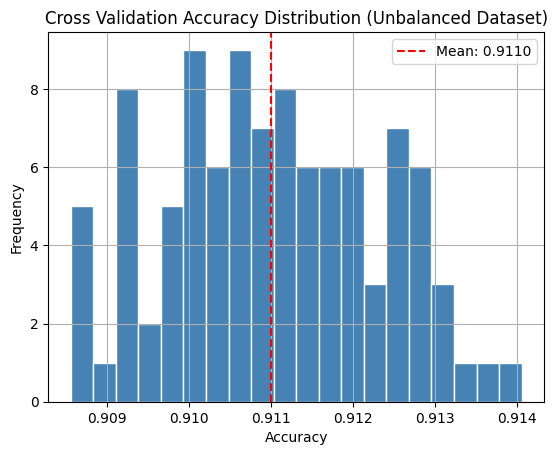

In [ ]:
# Histogram of Cross Validation accuracy scores
pd.Series(results).hist(bins = 20, color = 'steelblue', edgecolor = 'white')
plt.title('Cross Validation Accuracy Distribution (Unbalanced Dataset)')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.axvline(results.mean(), color = 'red', linestyle = '--', label = f'Mean: {results.mean():.4f}')
plt.legend()
plt.show()

In [ ]:
# Final train/test split and fit for confusion matrix
X_train, X_test, y_train, y_test, = train_test_split(X, y, test_size = 0.20)
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

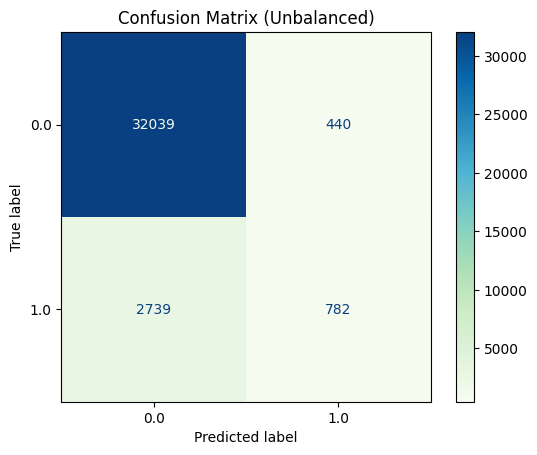

In [ ]:
# Confusion matrix of the unbalanced dataset
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize = None,
    values_format = 'd',
    cmap = 'GnBu',
)
plt.grid(False)
plt.title('Confusion Matrix (Unbalanced)')
plt.show()

In [ ]:
# Classification report of the Unbalanced Dataset
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     32479
         1.0       0.64      0.22      0.33      3521

    accuracy                           0.91     36000
   macro avg       0.78      0.60      0.64     36000
weighted avg       0.89      0.91      0.89     36000



### Interpretation of the Unbalanced Dataset

The confusion matrix and classification report reveal a model heavily biased toward predicting class `0`. Because ~90% of training examples are non-transactions, the model defaults to that prediction. This produces high raw accuracy but a very poor recall for class `1` - the **successful transactions** I care about.

The cross validation histogram displays a tight, consistent distribution (low variance across splits). However, the high mean accuracy is misleading and driven by class imbalance, not genuine predictive power.

In [ ]:
# Balancing the data to sample an equal number of unsuccessful transactions as successful ones
# This prevents the model from being biased toward predicting 0
df_0_sampled = df_0.sample(n = df_1.shape[0], random_state = 0)
df_bal = pd.concat([df_0_sampled, df_1])

print(f'Balanced dataset shape: {df_bal.shape}')
print(df_bal['target'].value_counts())

Balanced dataset shape: (36080, 51)
target
0.0    18040
1.0    18040
Name: count, dtype: int64


In [ ]:
# Redefine X and y from balanced dataset
X_bal = df_bal.drop(columns = ['target']).copy()
y_bal = df_bal['target'].copy()
print(X_bal.shape, y_bal.shape)

(36080, 50) (36080,)


In [ ]:
# Run 100-iteration cross-validation on the balanced dataset
results_bal = run_cv(X_bal, y_bal)
print(f'Cross Validation Mean Accuracy (balanced): {results_bal.mean():.4f}')

Cross Validation Mean Accuracy (balanced): 0.7546


## 6. Data Visualization/Communication of Results

Now to compare the Performance of the model on the unbalanced VS. balanced dataset and present the final confusion matrix and classification report. The key question is: ***did balancing the data improve our ability to identify successful transactions?***

| Question | Answer |
|---|---|
| What did the plots show? | Balancing dropped accuracy from 0.91 to 0.75 but made class 1 predictions meaningful |
| What could improve performance? | SMOTE oversampling, feature selection, ensemble methods |
| Next steps? | See Conclusion section |

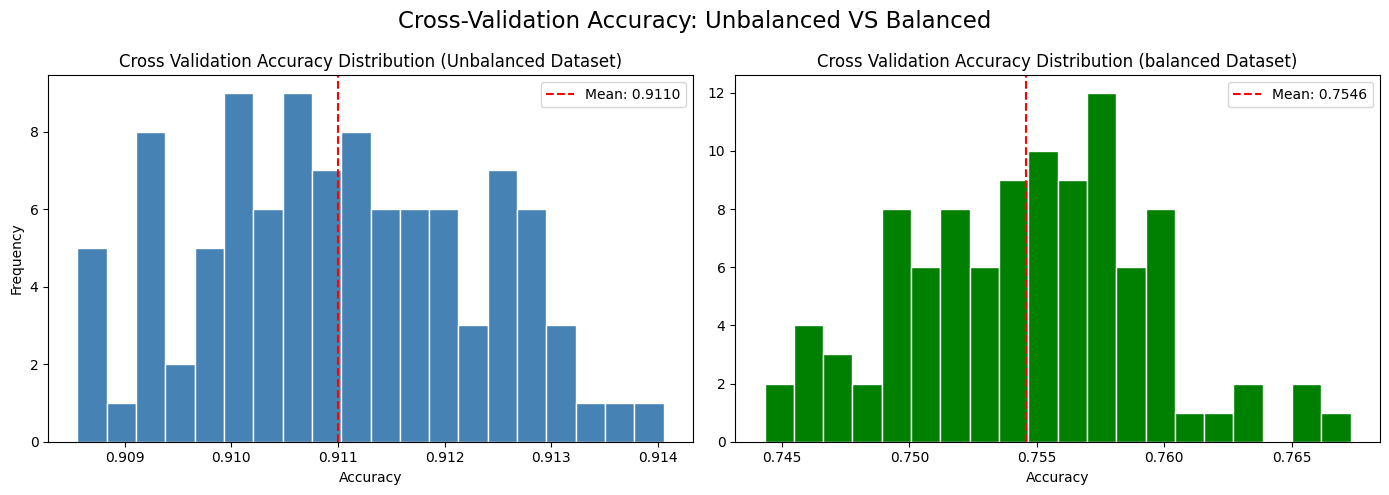

Cross Validation Mean Accuracy (unbalanced): 0.9110
Cross Validation Mean Accuracy (balanced): 0.7546


In [ ]:
# Comparision of accuracy distributions: unbalanced VS balanced
fig, axes = plt.subplots(1, 2, figsize = (14, 5), sharey = False, sharex = False)

axes[0].hist(results, bins = 20, color = 'steelblue', edgecolor = 'white')
axes[0].axvline(results.mean(), color = 'red', linestyle = '--', label = f'Mean: {results.mean():.4f}')
axes[0].set_title('Cross Validation Accuracy Distribution (Unbalanced Dataset)')
axes[0].set_xlabel('Accuracy')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(results_bal, bins = 20, color = 'green', edgecolor = 'white')
axes[1].axvline(results_bal.mean(), color = 'red', linestyle = '--', label = f'Mean: {results_bal.mean():.4f}')
axes[1].set_title('Cross Validation Accuracy Distribution (balanced Dataset)')
axes[1].set_xlabel('Accuracy')
axes[1].legend()

plt.suptitle('Cross-Validation Accuracy: Unbalanced VS Balanced', fontsize = 16.5)
plt.tight_layout()
plt.show()

print(f'Cross Validation Mean Accuracy (unbalanced): {results.mean():.4f}')
print(f'Cross Validation Mean Accuracy (balanced): {results_bal.mean():.4f}')



In [ ]:
# Final train/test split and fit for confusion matrix
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(X_bal, y_bal, test_size = 0.20)
gnb_bal = GaussianNB()
gnb_bal.fit(X_train_bal, y_train_bal)
y_pred_bal = gnb_bal.predict(X_test_bal)

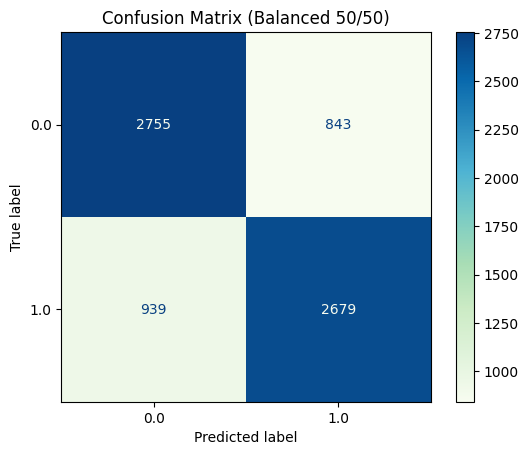

In [ ]:
# Confusion matrix of the balanced dataset
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test_bal,
    y_pred_bal,
    normalize = None,
    values_format = 'd',
    cmap = 'GnBu',
)
plt.grid(False)
plt.title('Confusion Matrix (Balanced 50/50)')
plt.show()


In [ ]:
# Classification report of the balanced Dataset
print(metrics.classification_report(y_test_bal, y_pred_bal))

              precision    recall  f1-score   support

         0.0       0.75      0.77      0.76      3598
         1.0       0.76      0.74      0.75      3618

    accuracy                           0.75      7216
   macro avg       0.75      0.75      0.75      7216
weighted avg       0.75      0.75      0.75      7216



### Results Interpretation

**Unbalanced model:** High raw accuracy (~90%) driven almost entirely by predicting class `0`. The confusion matrix shows the model rarely predicts class `1`, and classification report reflects poor recall for successful transactions.

**Balanced model:** Raw accuracy drops, but the model now predicts both classes. Recall for class `1` improves, this metric matters most for identifying successful transactions.

The side-by-side histogram confirms the key trade-off: the unbalanced distribution clusters tightly near 90% (deceptive accuracy), while the balanced distribution reflects a more truthful discriminative ability to predict.

---

## 7. Conclusion

$$\text{Accuracy}_{\text{unbalanced}} \approx \textit 0.9111$$
$$\text{Accuracy}_{\text{balanced}} \approx \textit 0.7551$$

The unbalanced model achieved high raw accuracy by defaulting to class `0` predictions -- since 90% of the data is non-transactions, always guessing 0 is right 90% of the time. **This is misleading and not a useful model.**

After balancing the dataset to a 50/50 split, accuracy reflects how well the model genuinely distinguishes between transactions and non-transactions. The confusion matrix and classification report give a clearer picture of false positives and false negatives.

### Future Work

- Try other models: decision tree, logistic regression, random forest
- Feature selection to identify the most predictive variables
- Use SMOTE (Synthetic Minority Over-sampling Technique) or other oversampling techniques instead of undersampling
- Tune the classification threshold to optimise the precision/recall trade-off
- Evaluate using AUC (Area Under the Curve) of the ROC (Receiver Operating Characteristic) for a threshold-independent performance metric